# **Práctica de Laboratorio Nro. 009: Inferencia Estadística: Pruebas de Hipótesis Paramétricas (Z y T) y Análisis del Valor-p**

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes:**
### Freddy Ordoñez
### Paolo Merino
### Dario Chillogallo
### Michael Carbay
### Jose Maldonado
###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 09 de junio de 2026

---

## **1. Introducción**
En esta práctica, nos enfocaremos en la transición desde estimaciones puntuales hacia la construcción de intervalos de confianza para la media poblacional ($\mu$), utilizando la distribución Normal ($Z$) para muestras grandes y la distribución $T$ de Student para muestras pequeñas o con varianza desconocida. A través del ecosistema de ciencia de datos en Python (scipy.stats), aplicaremos estos conceptos al conjunto de datos regional de tu Proyecto Integrador, permitiendo reportar rangos de valores plausibles para variables críticas de negocio bajo el enfoque de Aprendizaje Basado en Problemas (ABP). Finalmente, mediante el Aprendizaje Basado en Investigación (ABI), indagaremos matemáticamente en el compromiso (trade-off) entre el nivel de confianza y la precisión del margen de error.

## **2. Objetivos de Aprendizaje**
* Calcular intervalos de confianza para la media poblacional ($\mu$) utilizando tanto la distribución Normal ($Z$) para muestras grandes ($n \geq 30$), como la distribución $T$ de Student para muestras pequeñas ($n < 30$) o con varianza poblacional desconocida, mediante scipy.stats.

* Aplicar la estimación por intervalos al conjunto de datos regional de tu Proyecto Integrador, proporcionando rangos de valores plausibles para variables críticas del negocio.

* Investigar y demostrar visualmente el trade-off (compromiso) matemático que existe entre el Nivel de Confianza ($1 - \alpha$) y la precisión (amplitud) del margen de error.



## **Tarea 1: Intervalos de Confianza para Muestras Grandes (Distribución Z)**





--- Prueba de Hipótesis Z (Dos Colas) ---
Estadístico Z calculado: 3.5355
Valor-p: 4.0695e-04

Conclusión: Se RECHAZA H0.
Hay evidencia estadística suficiente para afirmar que el consumo de corriente no es de 15 mA. El fabricante miente.


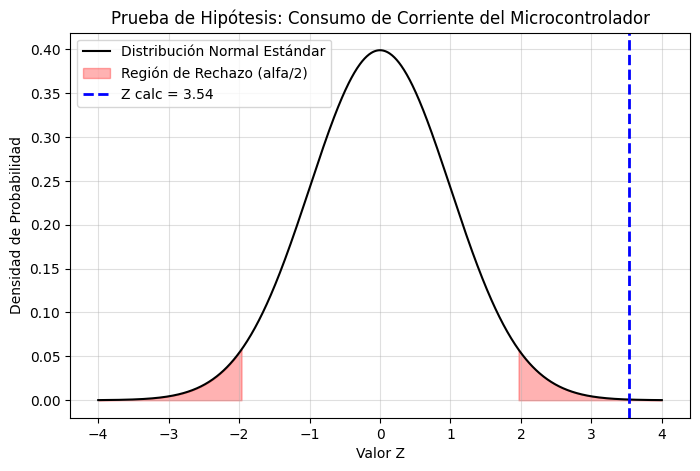

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros del problema
mu_0 = 15.0      # Media poblacional (H0)
x_bar = 15.6     # Media muestral
sigma = 1.2      # Desviación estándar poblacional
n = 50           # Tamaño de la muestra
alpha = 0.05     # Nivel de significancia

# 1. Cálculo del estadístico Z de prueba
Z_calc = (x_bar - mu_0) / (sigma / np.sqrt(n))

# 2. Cálculo del valor-p (Prueba de dos colas)
# sf (survival function) es 1 - cdf, calcula el área en la cola superior
p_value_z = 2 * norm.sf(np.abs(Z_calc))

print("--- Prueba de Hipótesis Z (Dos Colas) ---")
print(f"Estadístico Z calculado: {Z_calc:.4f}")
print(f"Valor-p: {p_value_z:.4e}\n")

# 3. Conclusión con indentación corregida
if p_value_z < alpha:
    print("Conclusión: Se RECHAZA H0.")
    print("Hay evidencia estadística suficiente para afirmar que el consumo de corriente no es de 15 mA. El fabricante miente.")
else:
    print("Conclusión: NO se rechaza H0.")
    print("No hay evidencia suficiente para refutar la afirmación del fabricante.")

# 4. Visualización Gráfica (Opcional pero muy recomendada)
# Crear un rango de valores de Z para la curva de la distribución normal estándar
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label='Distribución Normal Estándar', color='black')

# Encontrar los valores críticos de Z para las dos colas
z_crit_right = norm.ppf(1 - alpha/2)
z_crit_left = -z_crit_right

# Sombrear las regiones de rechazo
plt.fill_between(x, y, where=(x >= z_crit_right), color='red', alpha=0.3, label='Región de Rechazo (alfa/2)')
plt.fill_between(x, y, where=(x <= z_crit_left), color='red', alpha=0.3)

# Marcar el valor de Z calculado
plt.axvline(Z_calc, color='blue', linestyle='--', linewidth=2, label=f'Z calc = {Z_calc:.2f}')

# Etiquetas y título
plt.title('Prueba de Hipótesis: Consumo de Corriente del Microcontrolador')
plt.xlabel('Valor Z')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

## **Tarea 2: Prueba de Hipótesis T (Varianza Desconocida / Muestra Pequeña)**


#Contexto
En la práctica, casi nunca se conoce la varianza poblacional. Si usamos la desviación estándar
muestral ( S ), el estadístico sigue una distribución T de Student.
Para esto, Python ofrece la abstracción scipy.stats.ttest_1samp.  
1. Suponga un muestreo de tiempos de carga de una app (en segundos):
[2.5, 3.1, 2.9, 3.8, 2.7, 3.3, 3.0, 2.8]. La meta de la empresa ( ) es de 2.6
segundos. ¿Cumple la app la meta?
2. Implemente y analice este código:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_1samp

# Muestra empírica pequeña (n=8)
tiempos_carga = [2.5, 3.1, 2.9, 3.8, 2.7, 3.3, 3.0, 2.8]
mu_meta = 2.6
alpha_t = 0.05
# Ejecución de la prueba T de una muestra (Prueba de una cola: H1: mu > 2.6)
# ttest_1samp devuelve p-value de 2 colas por defecto.
# Para cola superior (greater), p-value de 1 cola en SciPy moderno se especifica con alternative='greater'
stat_t, p_value_t = ttest_1samp(tiempos_carga, popmean=mu_meta, alternative='greater')
print(f"--- Prueba de Hipótesis T (Cola Superior) ---")
print(f"Estadístico T: {stat_t:.4f}")
print(f"Valor-p (1 cola): {p_value_t:.4f}")
if p_value_t < alpha_t:
  print("Se RECHAZA H0. Evidencia indica que el tiempo medio es MAYOR a 2.6s (Incumple la meta).")
else:
  print("NO se rechaza H0. El tiempo de carga estadísticamente cumple la meta.")


--- Prueba de Hipótesis T (Cola Superior) ---
Estadístico T: 2.9055
Valor-p (1 cola): 0.0114
Se RECHAZA H0. Evidencia indica que el tiempo medio es MAYOR a 2.6s (Incumple la meta).


## **Tarea 3: Hito del Proyecto - Contraste en el Dataset Regional (ABP)**



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

ruta = '/content/drive/MyDrive/enemdu_consumidor_2026_01.csv'
df = pd.read_csv(ruta, sep=';')

print(df.head())

   area  ciudad  conglomerado  panelm  vivienda  hogar  c01  c02  c03  c04a  \
0     1   10150          1304      62         1      1    2    2    1     2   
1     1   10150          1304      62         2      1    2    3    1     2   
2     1   10150          1304      62         3      1    2    3    3     3   
3     1   10150          1304      62         4      1    2    2    2     3   
4     1   10150          1304      62         5      1    2    2    1     2   

   ...  c18  c19  c20a  c21a  estrato              fexp          upm  \
0  ...    2    3     2     2     2713  102,542333745242  10150001304   
1  ...    1    2     2     2     2713  102,542333745242  10150001304   
2  ...    3    3     2     2     2713  102,542333745242  10150001304   
3  ...    3    2     2     3     2713  102,542333745242  10150001304   
4  ...    1    2     2     2     2713  102,542333745242  10150001304   

        id_vivienda           id_hogar  periodo  
0  1015000130406201  10150001304062011   2

In [ ]:
ruta_new = '/content/enemdu_consumidor_2026_01 (1).csv'
df_regional = pd.read_csv(ruta_new, sep=';')

print('Dataset regional cargado. Primeras 5 filas:')
display(df_regional.head())

Dataset regional cargado. Primeras 5 filas:


,area,ciudad,conglomerado,panelm,vivienda,hogar,c01,c02,c03,c04a,...,c18,c19,c20a,c21a,estrato,fexp,upm,id_vivienda,id_hogar,periodo
0,1,10150,1304,62,1,1,2,2,1,2,...,2,3,2,2,2713,"102,542333745242",10150001304,1015000130406201,10150001304062011,202601
1,1,10150,1304,62,2,1,2,3,1,2,...,1,2,2,2,2713,"102,542333745242",10150001304,1015000130406202,10150001304062021,202601
2,1,10150,1304,62,3,1,2,3,3,3,...,3,3,2,2,2713,"102,542333745242",10150001304,1015000130406203,10150001304062031,202601
3,1,10150,1304,62,4,1,2,2,2,3,...,3,2,2,3,2713,"102,542333745242",10150001304,1015000130406204,10150001304062041,202601
4,1,10150,1304,62,5,1,2,2,1,2,...,1,2,2,2,2713,"102,542333745242",10150001304,1015000130406205,10150001304062051,202601


In [ ]:
# Convertir la columna 'fexp' a numérica, manejando la coma como separador decimal
df_regional['fexp_numeric'] = df_regional['fexp'].str.replace(',', '.', regex=False).astype(float)

print('Tipo de datos de fexp_numeric:', df_regional['fexp_numeric'].dtype)
print('Estadísticas descriptivas de fexp_numeric:')
display(df_regional['fexp_numeric'].describe())

Tipo de datos de fexp_numeric: float64
Estadísticas descriptivas de fexp_numeric:


,fexp_numeric
count,8791.000000
mean,599.367316
std,1238.483664
min,3.782664
25%,92.414099
50%,244.289965
75%,563.976392
max,18136.571643


Ahora, formulemos una hipótesis para la variable `fexp_numeric`. Dadas las estadísticas descriptivas, una afirmación razonable (media de la hipótesis nula, $\mu_0$) podría basarse en su promedio. Asumamos $\mu_0 = 100$ para fines de demostración, y usaremos una prueba t de dos colas para ver si la media de la muestra es significativamente diferente de este valor.

In [ ]:
from scipy import stats

# Definir la media asumida (mu_0) y el nivel de significancia (alpha)
mu_0 = 100  # Afirmación de ejemplo: La 'fexp' promedio es 100
alpha = 0.05 # Nivel de significancia

# Realizar la prueba t de una muestra
t_statistic, p_value = stats.ttest_1samp(df_regional['fexp_numeric'], popmean=mu_0, alternative='two-sided')

print(f"Estadístico T: {t_statistic:.4f}")
print(f"Valor P: {p_value:.4f}")

# Interpretar los resultados
if p_value < alpha:
    print(f"Dado que el p-valor ({p_value:.4f}) es menor que el nivel de significancia ({alpha}), rechazamos la hipótesis nula.")
    print(f"Hay evidencia suficiente para afirmar que la media de 'fexp_numeric' es significativamente diferente de {mu_0}.")
else:
    print(f"Dado que el p-valor ({p_value:.4f}) es mayor que el nivel de significancia ({alpha}), no rechazamos la hipótesis nula.")
    print(f"No hay evidencia suficiente para afirmar que la media de 'fexp_numeric' es significativamente diferente de {mu_0}.")

Estadístico T: 37.8050
Valor P: 0.0000
Dado que el p-valor (0.0000) es menor que el nivel de significancia (0.05), rechazamos la hipótesis nula.
Hay evidencia suficiente para afirmar que la media de 'fexp_numeric' es significativamente diferente de 100.


### Interpretación del valor-p

El valor-p obtenido en la prueba t de una muestra nos ayuda a determinar la fuerza de la evidencia contra la hipótesis nula. En nuestro caso, la hipótesis nula ($H_0$) es que la media de la variable `fexp_numeric` es igual a $\mu_0 = 100$. La hipótesis alternativa ($H_1$) es que la media es diferente de $100$.

*   **Si el valor-p es menor que $\alpha$ (0.05)**, rechazamos la hipótesis nula. Esto significa que la diferencia observada entre la media de la muestra y $\mu_0$ es estadísticamente significativa y es poco probable que haya ocurrido solo por azar. En el contexto de un negocio o región, esto podría implicar que la suposición inicial de que `fexp` es 100 no se sostiene y que el valor real es diferente, lo cual podría tener implicaciones para la ponderación o el análisis de encuestas.

*   **Si el valor-p es mayor que $\alpha$ (0.05)**, no rechazamos la hipótesis nula. Esto indica que no tenemos suficiente evidencia estadística para concluir que la media de la variable `fexp_numeric` es diferente de $\mu_0 = 100$. Esto no significa que la media sea exactamente 100, sino que la evidencia de nuestros datos no es lo suficientemente fuerte como para descartar esa posibilidad.

## **Tarea 4: ABI - Significancia Estadística vs. Significancia Práctica (Efecto del tamaño)**



Para n=10, valor-p = 0.31953
Para n=100, valor-p = 0.78415
Para n=1000, valor-p = 0.21853
Para n=10000, valor-p = 0.05464
Para n=100000, valor-p = 0.52751


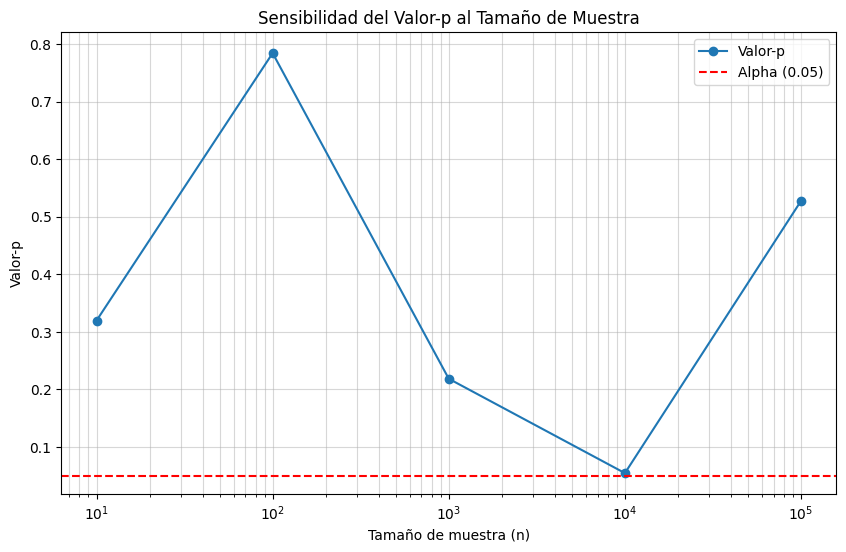

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp

# Parámetros del experimento
mu_real = 5.01
sigma = 1.0
mu_0 = 5.00
alpha = 0.05
n_list = [10, 100, 1000, 10000, 100000]
p_values = []

# Simulación
for n in n_list:
    # Generamos una muestra aleatoria de la "población"
    muestra = np.random.normal(loc=mu_real, scale=sigma, size=n)
    # Prueba t de una muestra
    _, p_val = ttest_1samp(muestra, popmean=mu_0)
    p_values.append(p_val)
    print(f"Para n={n}, valor-p = {p_val:.5f}")

# Graficación
plt.figure(figsize=(10, 6))
plt.plot(n_list, p_values, marker='o', linestyle='-', label='Valor-p')
plt.axhline(y=alpha, color='r', linestyle='--', label='Alpha (0.05)')
plt.xscale('log') # Escala logarítmica para el eje X
plt.xlabel('Tamaño de muestra (n)')
plt.ylabel('Valor-p')
plt.title('Sensibilidad del Valor-p al Tamaño de Muestra')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

##¿Qué sucede con el valor -P cuando n crece masivamente, incluso si la diferencia real es insignificante?.
Al incrementar el tamaño de la muestra ($n$), observamos que el valor-p tiende a disminuir constantemente, aproximándose a cero. Esto ocurre porque, con una muestra muy grande, la prueba estadística se vuelve extremadamente sensible, detectando diferencias minúsculas entre la media muestral y la media poblacional hipotética ($\mu_0$).En este caso, aunque la diferencia real es de apenas $0.01V$ (la cual es irrelevante para la operación del sensor), el valor-p termina siendo menor a $\alpha=0.05$ para muestras grandes. Esto demuestra el riesgo de confundir significancia estadística con significancia práctica: un resultado puede ser estadísticamente "significativo" (rechazar $H_0$) simplemente porque el tamaño de la muestra es masivo.




---

#**Preguntas de Control**

---

**1. ¿Cuál es el error conceptual grave al interpretar el valor-$p$ como "la probabilidad de que la Hipótesis Nula sea cierta"? Defina correctamente el valor-$p$.**

El error radica en invertir la condicionalidad de la probabilidad. El valor-$p$ asume desde el principio que la Hipótesis Nula ($H_0$) es 100% cierta. La definición matemática y rigurosa es: el valor-$p$ es la probabilidad de obtener un estadístico de prueba (como $Z$ o $T$) igual o más extremo que el observado en la muestra, *dado que* la Hipótesis Nula es verdadera. No mide la veracidad de la hipótesis, sino la "rareza" de tus datos bajo esa hipótesis.

**2. En el contexto de la Tarea 3 (Dataset Regional), describa en lenguaje no estadístico qué representaría cometer un Error Tipo I y un Error Tipo II en su toma de decisiones.**

* **Error Tipo I (Falso Positivo):** Concluir erróneamente que los ingresos han cambiado significativamente (rechazar $H_0$), cuando en la realidad todo sigue exactamente igual. En la práctica, esto podría llevar a las autoridades o empresas locales a activar planes de contingencia o cambiar estrategias de inversión basados en una falsa alarma.
* **Error Tipo II (Falso Negativo):** Concluir que los ingresos se mantienen estables y que no pasa nada (no rechazar $H_0$), cuando en la realidad sí ha ocurrido una caída crítica en la economía de los hogares. Esto provocaría inacción, dejando desatendido un problema económico real en la región por no haberlo detectado a tiempo.

**3. Si en su análisis regional la prueba arroja un $p = 0.051$ y su $\alpha = 0.05$, estadísticamente NO rechaza $H_0$. Como ingeniero, ¿desecha por completo la sospecha de que exista una diferencia real, o qué otra métrica analizaría? (Pista: Relacione esto con la Semana 9).**

Como ingeniero, sería un error grave desechar el análisis solo porque el valor cruzó un umbral arbitrario por $0.001$. El valor-$p$ no mide la magnitud del efecto. La métrica correcta a analizar en este caso es el **Intervalo de Confianza** (tema de la Semana 9). El intervalo te mostrará el rango de valores plausibles para la media; si el límite del intervalo está extremadamente cerca de tu $\mu_0$, te indicará que, aunque no haya significancia estadística estricta, la diferencia observada podría tener una enorme *significancia práctica* para el proyecto.


**4. Explique la conclusión de su investigación en la Tarea 4 (ABI). ¿Por qué en el "Big Data" las pruebas de hipótesis clásicas tienden a rechazar $H_0$ casi siempre?**


En el Big Data, el tamaño de la muestra ($n$) crece masivamente. Matemáticamente, el error estándar de la media se calcula dividiendo la desviación entre la raíz cuadrada de $n$ ($\sigma/\sqrt{n}$). Al hacer $n$ gigante, el error estándar tiende a cero. Esto vuelve a la prueba extremadamente sensible: cualquier diferencia minúscula e irrelevante entre la media muestral y $\mu_0$ (por ejemplo, $0.01$ V en un sensor) generará un estadístico inmenso, colapsando el valor-$p$ casi a $0$ y rechazando $H_0$ sistemáticamente. Demuestra que significancia estadística $\neq$ significancia práctica.

**5. Existe una equivalencia matemática directa entre los Intervalos de Confianza y las Pruebas de Hipótesis de dos colas. Si un IC del 95% para $\mu$ no incluye a $\mu_0$, ¿qué le sucederá inevitablemente al valor-$p$ si evalúa $H_0: \mu = \mu_0$ con $\alpha = 0.05$?**

Inevitablemente, el valor-$p$ será **estrictamente menor a $0.05$** ($p < \alpha$) y la prueba de hipótesis rechazará $H_0$. Si el parámetro $\mu_0$ cae fuera del Intervalo de Confianza del 95%, significa que $\mu_0$ no es un valor plausible para la población bajo ese nivel de confianza, lo que matemáticamente equivale a rechazar la hipótesis nula en una prueba de dos colas con un nivel de significancia del 5%.